In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
base = Path.cwd()
candidates = [base, base.parent, Path("/mnt/data")]
def locate(name):
    for p in candidates:
        q = p / name
        if q.exists():
            return q
    raise FileNotFoundError(name)
details = pd.read_csv(locate("order_details(3).csv"))
timestamps = pd.read_csv(locate("order_timestamp(3).csv"))
for c in ["start_time_slot", "accept_time", "arrived_pickup_at"]:
    timestamps[c] = pd.to_datetime(timestamps[c], errors="coerce")
details["created_date"] = pd.to_datetime(details["created_date"], errors="coerce")
df = details.merge(timestamps, on="order_id", how="inner", validate="one_to_one")
df["BART_raw_min"] = (df["arrived_pickup_at"] - df["start_time_slot"]).dt.total_seconds()/60
df["BART_min"] = df["BART_raw_min"].clip(lower=0)
df["Acceptance_raw_min"] = (df["accept_time"] - df["start_time_slot"]).dt.total_seconds()/60
df["Acceptance_min"] = df["Acceptance_raw_min"].clip(lower=0)
df["Arrival_raw_min"] = (df["arrived_pickup_at"] - df["accept_time"]).dt.total_seconds()/60
df["Arrival_min"] = df["Arrival_raw_min"].clip(lower=0)
df["BART15"] = np.where(df["BART_min"].notna(), (df["BART_min"] <= 15).astype(int), np.nan)
df["hour"] = df["start_time_slot"].dt.hour
df["weekday"] = df["start_time_slot"].dt.day_name()
df["month"] = df["start_time_slot"].dt.month_name()
df["month_num"] = df["start_time_slot"].dt.month
df["date"] = df["start_time_slot"].dt.date
df["hour_bucket"] = df["start_time_slot"].dt.floor("h")
df["distance_km"] = df["total_distance"]/1000
df["fare_m"] = df["order_fare"]/1_000_000
df["fare_per_km"] = np.where(df["distance_km"]>0, df["order_fare"]/df["distance_km"], np.nan)
df["delayed_flag"] = np.where(df["order_offer_badge"].notna(), (df["order_offer_badge"].astype(str).str.lower()=="delayed").astype(int), np.nan)
df["district_str"] = df["district"].astype("Int64").astype(str)
df["city_district"] = df["order_city"].astype(str)+"-"+df["district_str"]
main = df[(df["start_time_slot"] >= pd.Timestamp("2025-08-01")) & (df["start_time_slot"] < pd.Timestamp("2025-11-01")) & df["BART_min"].notna()].copy()
seq = main[(main["start_time_slot"] <= main["accept_time"]) & (main["accept_time"] <= main["arrived_pickup_at"])].copy()
fig_dir = Path("assets/figures")
table_dir = Path("assets/tables")
fig_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)
def savefig(name):
    plt.tight_layout()
    plt.savefig(fig_dir/name, dpi=220, bbox_inches="tight")
    plt.show()
def save_table(data, name, decimals=2):
    x = data.copy()
    for c in x.select_dtypes(include=["float", "float64", "float32"]).columns:
        x[c] = x[c].round(decimals)
    x.to_csv(table_dir/(name.replace(".png", ".csv")), index=False)
    display(x)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score, balanced_accuracy_score, accuracy_score
from lightgbm import LGBMClassifier


/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-axpzuh3q because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


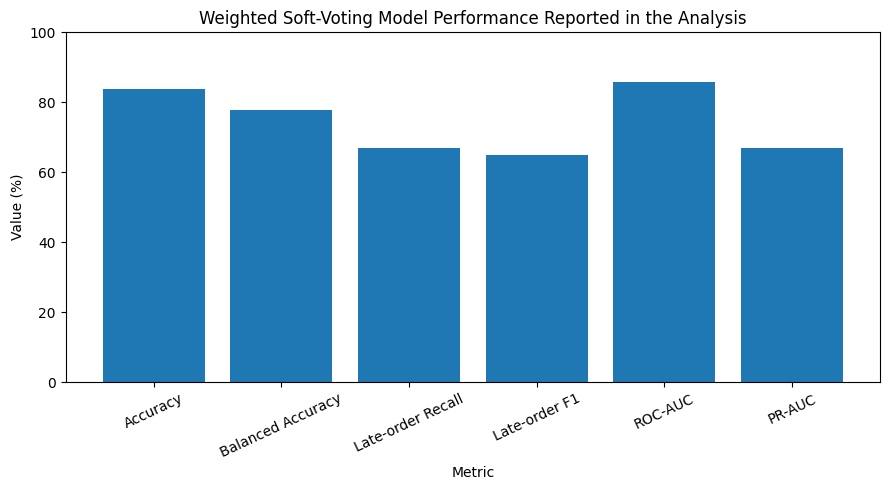

,Metric,Value
0,Accuracy,83.8
1,Balanced Accuracy,77.8
2,Late-order Recall,66.9
3,Late-order F1,65.0
4,ROC-AUC,85.8
5,PR-AUC,67.0


In [2]:
reported=pd.DataFrame({"Metric":["Accuracy","Balanced Accuracy","Late-order Recall","Late-order F1","ROC-AUC","PR-AUC"],"Value":[83.8,77.8,66.9,65.0,85.8,67.0]})
fig, ax=plt.subplots(figsize=(9,5))
ax.bar(reported["Metric"],reported["Value"])
ax.set_ylim(0,100)
ax.set_title("Weighted Soft-Voting Model Performance Reported in the Analysis")
ax.set_xlabel("Metric")
ax.set_ylabel("Value (%)")
ax.tick_params(axis="x",rotation=25)
savefig("F33_ML_Reported_Performance.png")
save_table(reported,"T11_ML_Reported_Performance.png")


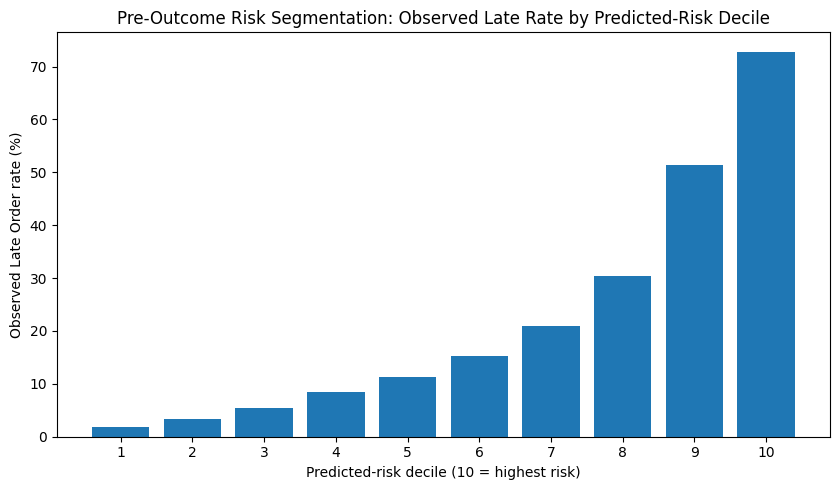

,Risk Decile,Orders,Observed Late Rate (%),Mean Predicted Risk (%)
0,1,6085,1.84,6.58
1,2,6085,3.37,11.65
2,3,6085,5.39,16.60
3,4,6085,8.55,23.85
4,5,6085,11.37,34.28
5,6,6084,15.27,45.24
6,7,6085,21.00,57.03
7,8,6085,30.37,69.79
8,9,6085,51.41,82.40
9,10,6085,72.83,90.53


In [3]:
m=main.copy().sort_values("start_time_slot")
m["weekday_num"]=m["start_time_slot"].dt.dayofweek
m["is_lunch_peak"]=m["hour"].between(11,13).astype(int)
m["is_dinner_peak"]=m["hour"].between(17,21).astype(int)
m["district_code"] = pd.factorize(m["city_district"])[0]
m["city_code"] = pd.factorize(m["order_city"])[0]
m["fare_per_km_m"] = m["fare_per_km"]/1_000_000
m["interval15"] = m["start_time_slot"].dt.floor("15min")
loads=m.groupby(["city_district","interval15"]).size().rename("interval_load").reset_index().sort_values(["city_district","interval15"])
loads["previous_15m_load"]=loads.groupby("city_district")["interval_load"].shift(1).fillna(0)
m=m.merge(loads[["city_district","interval15","previous_15m_load"]],on=["city_district","interval15"],how="left")
features=["month_num","weekday_num","hour","is_lunch_peak","is_dinner_peak","city_code","district_code","batch","fare_m","distance_km","fare_per_km_m","previous_15m_load"]
model_df=m.dropna(subset=features+["BART15"]).copy()
train=model_df[model_df["month_num"]<=9]
test=model_df[model_df["month_num"]==10]
X_train=train[features]; y_train=(1-train["BART15"]).astype(int)
X_test=test[features]; y_test=(1-test["BART15"]).astype(int)
model=LGBMClassifier(n_estimators=220,learning_rate=.05,num_leaves=31,subsample=.9,colsample_bytree=.9,class_weight="balanced",random_state=42,n_jobs=-1,verbosity=-1)
model.fit(X_train,y_train)
risk=model.predict_proba(X_test)[:,1]
auc=roc_auc_score(y_test,risk)
prauc=average_precision_score(y_test,risk)
risk_decile=pd.qcut(risk,10,labels=False,duplicates="drop")+1
risk_table=pd.DataFrame({"Risk_Decile":risk_decile,"Late":y_test.values,"Risk":risk}).groupby("Risk_Decile").agg(Orders=("Late","size"),Observed_Late_Rate=("Late","mean"),Mean_Predicted_Risk=("Risk","mean")).reset_index()
risk_table["Observed_Late_Rate"]*=100
risk_table["Mean_Predicted_Risk"]*=100
fig, ax=plt.subplots(figsize=(8.5,5))
ax.bar(risk_table["Risk_Decile"].astype(str),risk_table["Observed_Late_Rate"])
ax.set_title("Pre-Outcome Risk Segmentation: Observed Late Rate by Predicted-Risk Decile")
ax.set_xlabel("Predicted-risk decile (10 = highest risk)")
ax.set_ylabel("Observed Late Order rate (%)")
savefig("F34_ML_Risk_Decile_Late_Rate.png")
risk_table_out=risk_table.rename(columns={"Risk_Decile":"Risk Decile","Observed_Late_Rate":"Observed Late Rate (%)","Mean_Predicted_Risk":"Mean Predicted Risk (%)"})
save_table(risk_table_out,"T12_ML_Risk_Decile_Table.png")


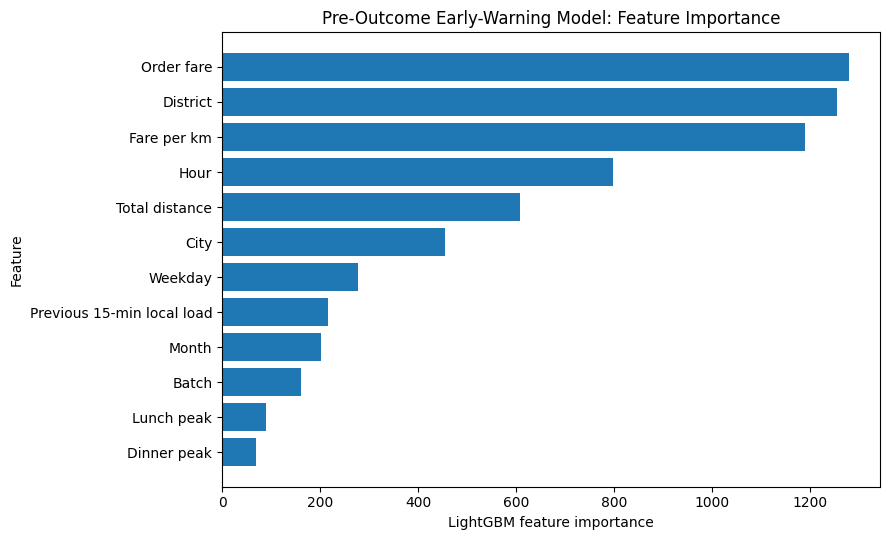

In [4]:
feature_labels={"month_num":"Month","weekday_num":"Weekday","hour":"Hour","is_lunch_peak":"Lunch peak","is_dinner_peak":"Dinner peak","city_code":"City","district_code":"District","batch":"Batch","fare_m":"Order fare","distance_km":"Total distance","fare_per_km_m":"Fare per km","previous_15m_load":"Previous 15-min local load"}
imp=pd.DataFrame({"Feature":[feature_labels[x] for x in features],"Importance":model.feature_importances_}).sort_values("Importance").tail(12)
fig, ax=plt.subplots(figsize=(9,5.5))
ax.barh(imp["Feature"],imp["Importance"])
ax.set_title("Pre-Outcome Early-Warning Model: Feature Importance")
ax.set_xlabel("LightGBM feature importance")
ax.set_ylabel("Feature")
savefig("F35_ML_Early_Warning_Feature_Importance.png")


,Action,Target,Impact,Effort,Feasibility,Owner,Activation
0,Peak-hour supply & repositioning,K-1480,Very High,Medium,Medium-High,City Operations + Biker Supply,10-20 min
1,Earlier offer-pool expansion & rescue,K-1512 / K-1528,High,Medium,Medium-High,Dispatch Operations + Product,5-15 min
2,High-risk rescue & targeted incentive,U-1400,Medium-High,Low-Medium,High,City Operations + Biker Operations,10-15 min
3,ETA-based assignment & pre-positioning,B-3740,High locally,Medium,Medium-High,Dispatch + City Operations,10-30 min
4,ML predictive early warning,Network / problem districts,High,Medium-High,Medium,Data/BI + Dispatch + Operations,Shadow now; 1-2 sprints


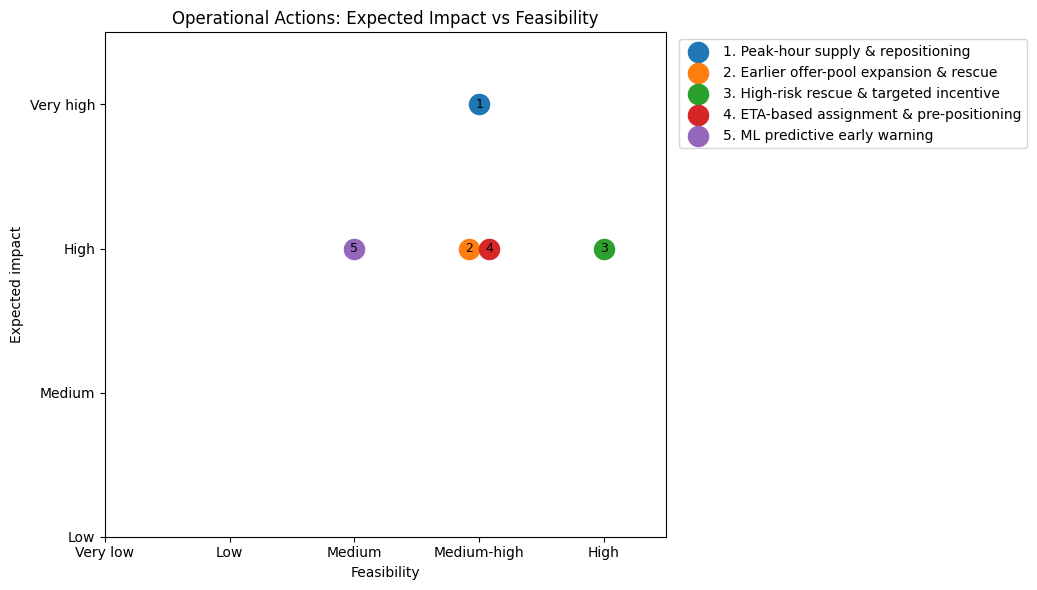

In [5]:
actions=pd.DataFrame([
    ["Peak-hour supply & repositioning","K-1480","Very High",4,"Medium",3,"Medium-High",4,"City Operations + Biker Supply","10-20 min"],
    ["Earlier offer-pool expansion & rescue","K-1512 / K-1528","High",3,"Medium",3,"Medium-High",4,"Dispatch Operations + Product","5-15 min"],
    ["High-risk rescue & targeted incentive","U-1400","Medium-High",3,"Low-Medium",2,"High",5,"City Operations + Biker Operations","10-15 min"],
    ["ETA-based assignment & pre-positioning","B-3740","High locally",3,"Medium",3,"Medium-High",4,"Dispatch + City Operations","10-30 min"],
    ["ML predictive early warning","Network / problem districts","High",3,"Medium-High",4,"Medium",3,"Data/BI + Dispatch + Operations","Shadow now; 1-2 sprints"]
],columns=["Action","Target","Impact","Impact_score","Effort","Effort_score","Feasibility","Feasibility_score","Owner","Activation"])
actions_out=actions.drop(columns=["Impact_score","Effort_score","Feasibility_score"])
actions_out.to_csv(table_dir/"T13_Action_Plan_Summary.csv",index=False)
display(actions_out)
fig, ax=plt.subplots(figsize=(10.5,6))
display_x=[4.0,3.92,5.0,4.08,3.0]
for i,(_,r) in enumerate(actions.iterrows(),start=1):
    ax.scatter(display_x[i-1],r["Impact_score"],s=210,label=f"{i}. {r['Action']}")
    ax.text(display_x[i-1],r["Impact_score"],str(i),ha="center",va="center",fontsize=9)
ax.set_xlim(1,5.5); ax.set_ylim(1,4.5)
ax.set_xticks([1,2,3,4,5],labels=["Very low","Low","Medium","Medium-high","High"])
ax.set_yticks([1,2,3,4],labels=["Low","Medium","High","Very high"])
ax.set_title("Operational Actions: Expected Impact vs Feasibility")
ax.set_xlabel("Feasibility")
ax.set_ylabel("Expected impact")
ax.legend(loc="upper left",bbox_to_anchor=(1.01,1),frameon=True)
savefig("F36_Action_Impact_vs_Feasibility.png")


In [6]:
pilots=pd.DataFrame([
    ["K-1480 supply repositioning","Peak windows with repositioning","Comparable peak windows / control district","Acceptance P90; BART15","Source-district BART15; Biker cost/order","30-60 min incident read; 1 week pilot"],
    ["K-1512/K-1528 offer expansion","Expanded candidate pool","Current dispatch logic","Acceptance P90; Delayed Offer Rate","Arrival P90","30-60 min read; 1 week pilot"],
    ["U-1400 targeted rescue","Expanded offer + rescue incentive","Current process","Acceptance P90; BART15","Incremental cost per Late Order avoided","1 week"],
    ["B-3740 ETA assignment","ETA-prioritized assignment","Current assignment","Arrival P90; BART15","Acceptance P90","30-60 min read; 1 week pilot"],
    ["ML predictive trigger","High-risk orders receiving early action","High-risk orders under current process","Late Orders prevented","Cost per Late Order avoided; calibration","1 week shadow + controlled pilot"]
],columns=["Pilot","Treatment","Control","Primary metrics","Guardrails","Evaluation window"])
pilots.to_csv(table_dir/"T14_Pilot_Design_and_Success_Metrics.csv",index=False)
display(pilots)


,Pilot,Treatment,Control,Primary metrics,Guardrails,Evaluation window
0,K-1480 supply repositioning,Peak windows with repositioning,Comparable peak windows / control district,Acceptance P90; BART15,Source-district BART15; Biker cost/order,30-60 min incident read; 1 week pilot
1,K-1512/K-1528 offer expansion,Expanded candidate pool,Current dispatch logic,Acceptance P90; Delayed Offer Rate,Arrival P90,30-60 min read; 1 week pilot
2,U-1400 targeted rescue,Expanded offer + rescue incentive,Current process,Acceptance P90; BART15,Incremental cost per Late Order avoided,1 week
3,B-3740 ETA assignment,ETA-prioritized assignment,Current assignment,Arrival P90; BART15,Acceptance P90,30-60 min read; 1 week pilot
4,ML predictive trigger,High-risk orders receiving early action,High-risk orders under current process,Late Orders prevented,Cost per Late Order avoided; calibration,1 week shadow + controlled pilot
